In [1]:
# ==========================================
# IMPORTS
# ==========================================
import torch
import torch.nn as nn
import timm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    cohen_kappa_score, confusion_matrix,
    roc_curve, auc, precision_recall_curve
)

d:\anaconda3\envs\bearing_ai\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ==========================================

# DEVICE

# ==========================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
# ==========================================
# FOLDER STRUCTURE
# ==========================================
BASE_DIR = "evaluation_plots"

os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(f"{BASE_DIR}/roc_individual", exist_ok=True)
os.makedirs(f"{BASE_DIR}/pr_individual", exist_ok=True)
os.makedirs(f"{BASE_DIR}/confusion", exist_ok=True)

In [4]:
train_dir = r"D:/SET2_EXPANDED_PROJECT/data_augmented/train"
test_dir  = r"D:/SET2_EXPANDED_PROJECT/data_augmented/test"

In [5]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [6]:
train_dataset = datasets.ImageFolder(train_dir, transform=transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=transform)

test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("Classes:", train_dataset.classes)

Classes: ['Bad', 'Good']


In [7]:
class CNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Linear(128*28*28,256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256,2)
        )

    def forward(self,x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


class RCA_EfficientNet(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        self.backbone = timm.create_model(
            "efficientnet_b0",
            pretrained=True,  
            num_classes=0
        )

        self.feat_dim = self.backbone.num_features

        self.attention = nn.Sequential(
            nn.Linear(self.feat_dim, self.feat_dim // 8),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(self.feat_dim // 8, self.feat_dim),
            nn.Sigmoid()
        )

        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(self.feat_dim, num_classes)

    def forward(self, x):
        feat = self.backbone(x)

        attn = self.attention(feat)

        feat = feat + (feat * attn)

        feat = self.dropout(feat)

        return self.classifier(feat)

In [9]:
def load_timm_model(name, path):
    model = timm.create_model(name, pretrained=False, num_classes=2)
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.eval()
    return model

def load_custom_model(model_class, path):
    model = model_class().to(device)
    model.load_state_dict(torch.load(path, map_location=device))
    model.eval()
    return model

models = {
    "CNN": load_custom_model(CNNModel, "models/cnn_baseline.pth"),
    "ResNet50": load_timm_model("resnet50", "models/resnet_50.pth"),
    "EfficientNet": load_timm_model("efficientnet_b0", "models/efficientnet_b0.pth"),
    "DeiT": load_timm_model("deit_small_patch16_224", "models/deit_small.pth"),
    "RCA_EfficientNet": load_custom_model(RCA_EfficientNet, "models/efficient_hybrid_v3.pth")
}

In [10]:
def evaluate(model):
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)[:,1]
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

results = {}

for name, model in models.items():
    print(f"Evaluating {name}...")
    results[name] = evaluate(model)

Evaluating CNN...
Evaluating ResNet50...
Evaluating EfficientNet...
Evaluating DeiT...
Evaluating RCA_EfficientNet...


In [11]:
rows = []

for name, (y_true, y_pred, _) in results.items():
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "Kappa": cohen_kappa_score(y_true, y_pred)
    })

df = pd.DataFrame(rows).sort_values(by="Accuracy", ascending=False)
display(df)

df.to_csv(f"{BASE_DIR}/metrics.csv", index=False)

,Model,Accuracy,Precision,Recall,F1,Kappa
4,RCA_EfficientNet,0.978610,0.969072,0.989474,0.979167,0.957194
0,CNN,0.973262,0.950000,1.000000,0.974359,0.946464
2,EfficientNet,0.967914,0.958763,0.978947,0.968750,0.935790
3,DeiT,0.967914,0.940594,1.000000,0.969388,0.935746
1,ResNet50,0.962567,0.958333,0.968421,0.963351,0.925102


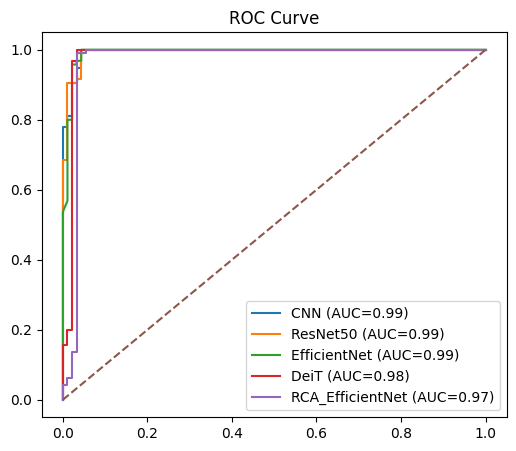

In [13]:
plt.figure(figsize=(6,5))

for name, (y_true, _, y_prob) in results.items():
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()

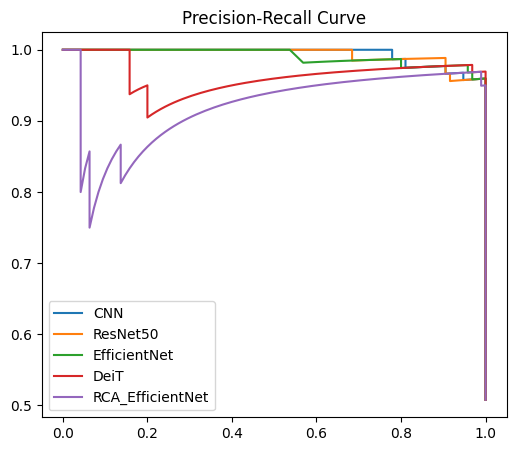

In [14]:
plt.figure(figsize=(6,5))

for name, (y_true, _, y_prob) in results.items():
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    plt.plot(recall, precision, label=name)

plt.legend()
plt.title("Precision-Recall Curve")
plt.show()

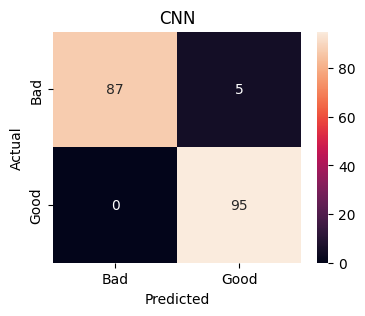

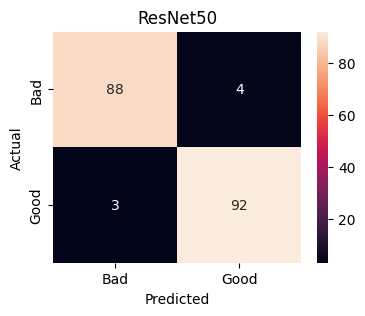

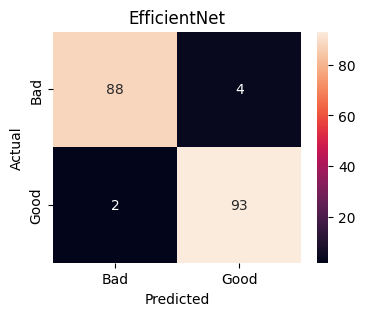

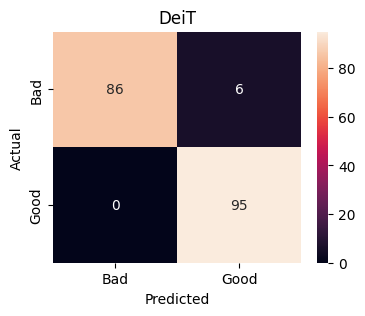

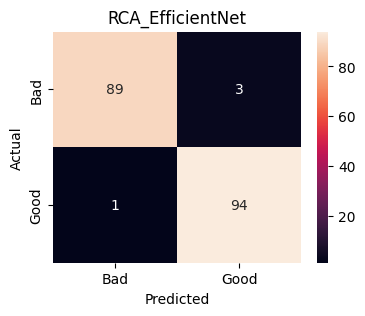

In [16]:
for name, (y_true, y_pred, _) in results.items():
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=["Bad","Good"],
                yticklabels=["Bad","Good"])
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()